<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/LeftTemporalLocalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

#### Setup Imports

!pip install mne
import mne
import os
import sys
import pickle
import numpy as np
import pandas as pd
import glob
import importlib

#Check if we are in colab.
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

#Load the correct base path depending on if we are in colab or not.
if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/Colab Notebooks/MNE/mne_data'
else:
    base_path = os.path.join(os.getcwd(), 'mne-data', 'MNE-sample-data')

sys.path.append('/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src')

import helper

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

##### Build Alignment Dataframe.

csv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data/M002_main_2025-04-14_13h48.34.684.csv"
df = pd.read_csv(csv_path)

df["audio_file"] = df["audio_file"].str.replace("\\", "/", regex=False)
df["audio_file"] = df["audio_file"].str.replace("../", "../", regex=False)

print(helper.__file__)

tsv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"

all_data = helper.stimuli_load(tsv_path)

meta_df = pd.DataFrame.from_dict(all_data, orient='index').reset_index()
meta_df.rename(columns={"index": "stimulus"}, inplace=True)
df = df.merge(meta_df, how="left", left_on="audio_file", right_on="stimulus")

df["global_onset"] = df["presentation.started"] + df["trigger_word_on.started"]

df["response_clean"] = pd.to_numeric(df["buttonBox_2.keys"], errors='coerce').fillna(-1).astype(int)

df["speaker_type"] = df["speaker"].apply(
    lambda s: "bot" if s in {"bot", "bot2"} else ("human" if pd.notna(s) else None)
)

def compute_resp_correct(row):
    if row["response_clean"] == -1 or pd.isna(row["tgt_sound"]) or pd.isna(row["sibilants"]):
        return None
    options = ["f", "θ"] if row["sibilants"] == "nonsibilant" else ["s", "ʃ"]
    if 0 <= row["response_clean"] < len(options):
        return row["tgt_sound"] == options[row["response_clean"]]
    return None

df["resp_correct"] = df.apply(compute_resp_correct, axis=1)

valid_df = df[df["response_clean"] != -1].copy()
valid_df = valid_df.sort_values("global_onset").reset_index(drop=True)

print(f"Trials in valid DataFrame: {len(valid_df)}")

alignment_df = valid_df
display(alignment_df)


/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/helper.py
Trials in valid DataFrame: 656


,thisN,thisTrialN,thisRepN,key_resp.keys,buttonBox_2.keys,buttonBox_2.rt,buttonBox_2.duration,key_resp_3.keys,key_resp_3.rt,key_resp_3.duration,...,perplexity,word_pair,wav_onset,wav_offset,tgt_word_onset,tgt_word_offset,global_onset,response_clean,speaker_type,resp_correct
0,0.0,0.0,0.0,NaN,1.0,0.430092,1.0,NaN,NaN,NaN,...,636.5484564957710,"""['sake', 'shake']""",0.1,1.79018,1.28472,1.79018,29.591400,1,human,True
1,1.0,0.0,1.0,NaN,0.0,0.488677,1.0,NaN,NaN,NaN,...,2796.690058614258,"""['said', 'shed']""",0.0,2.2543310657596374,1.7006665711369544,2.2543310657596374,32.370186,0,bot,True
2,2.0,0.0,2.0,NaN,1.0,0.378663,1.0,NaN,NaN,NaN,...,281.6849467843800,"""['self', 'shelf']""",0.1,1.8701500000000000,1.3094700000000000,1.8701500000000000,34.838499,1,human,False
3,3.0,0.0,3.0,NaN,1.0,0.614011,1.0,NaN,NaN,NaN,...,224.39023593088143,"""['sore', 'shore']""",0.0,1.937687074829932,1.3744470378571763,1.937687074829932,37.282689,1,bot,True
4,4.0,0.0,4.0,NaN,0.0,0.352167,1.0,NaN,NaN,NaN,...,295.14456406456300,"""['suit', 'shoot']""",0.1,2.56502,1.6796200000000000,2.56502,40.252699,0,human,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,651.0,0.0,651.0,NaN,0.0,0.566488,1.0,NaN,NaN,NaN,...,1560.6567047852400,"""['froze', 'throws']""",0.1,2.23852,1.6439300000000000,2.23852,1932.401549,0,human,True
652,652.0,0.0,652.0,NaN,1.0,0.399263,1.0,NaN,NaN,NaN,...,98.59642184449290,"""['fought', 'thought']""",0.1,1.5747200000000000,1.03778,1.5747200000000000,1934.728486,1,human,False
653,653.0,0.0,653.0,NaN,1.0,0.493154,1.0,NaN,NaN,NaN,...,577.4851867363460,"""['frill', ‘thrill']""",0.1,2.3650100000000000,1.8728300000000000,2.3650100000000000,1937.660632,1,human,True
654,654.0,0.0,654.0,NaN,0.0,0.505484,1.0,NaN,NaN,NaN,...,439.37813336037100,"""['fin', 'thin']""",0.0,1.6956462585034000,1.2518186269677,1.6956462585034000,1940.013805,0,bot,True


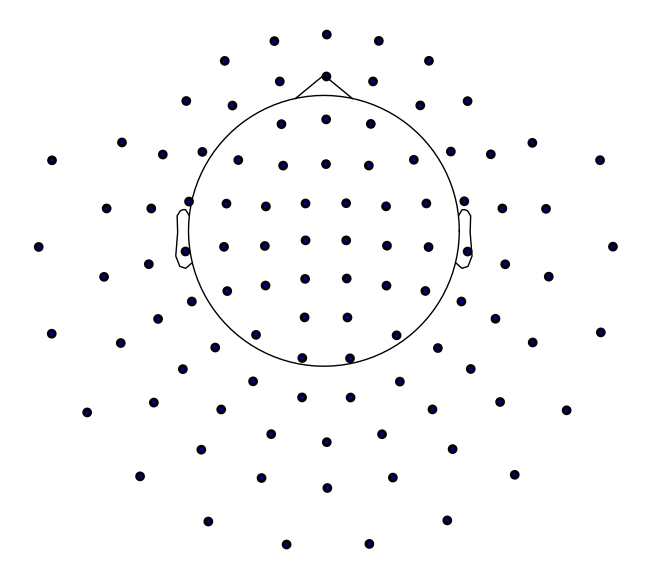

2644 events found on stim channel STI101
Event IDs: [  11   12   13   21   22   23   31   32   33   41   42   43   48   52
   53   61   62   63   71   72   73   81   82   83  256  267  268  277
  287  297  307  317  327  337  512  523  533  543  553  563  564  565
  573  583  593  594  768  829 1024]


ValueError: You have 3 events shorter than the shortest_event. These are very unusual and you may want to set min_duration to a larger value e.g. x / raw.info['sfreq']. Where x = 1 sample shorter than the shortest event length.

In [3]:
#Looking at MEG .fif files and plotting them.

raw_list = []
base_path2 = "/content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414"
for i in range(8):
    fpath = os.path.join(base_path2, f'M002_block{i}_raw.fif')
    raw = mne.io.read_raw_fif(fpath, preload=True, verbose='ERROR')
    raw_list.append(raw)

raw_combined = mne.concatenate_raws(raw_list, on_mismatch='ignore')

raw_combined.plot_sensors(kind='topomap')

# Get all sensor positions
positions = raw_combined.info['chs']
left_temporal_channels = []

events = mne.find_events(raw_combined)
mne.viz.plot_events(events, sfreq=raw_combined.info['sfreq'])  # Optional visualization

#This is repeated below using a fixed window of 1.5 seconds.

# PARAMETERS
sfreq = raw_combined.info['sfreq']
fixed_window_sec = 0.5  # in seconds
fixed_window_samples = int(fixed_window_sec * sfreq)

# Pick MEG channels
meg_picks = mne.pick_types(raw_combined.info, meg=True, stim=False, eog=False, exclude='bads')

# Extract trials
X_raw = []
y = []

for _, row in alignment_df.iterrows():
    if row.get("normality") not in ["normal", "abnormal"]:
        continue
    if pd.isna(row.get("global_onset")):
        continue

    onset_sample = int(row["global_onset"] * sfreq)

    if onset_sample < 0 or onset_sample + fixed_window_samples > raw_combined.n_times:
        continue

    data = raw_combined.get_data(
        picks=meg_picks,
        start=onset_sample,
        stop=onset_sample + fixed_window_samples
    )

    X_raw.append(data[np.newaxis, ...])
    y.append(1 if row["normality"] == "abnormal" else 0)

X_raw = np.concatenate(X_raw, axis=0)
y = np.array(y)

print(f"Extracted {X_raw.shape[0]} trials with shape {X_raw.shape}")

left_temporal_indices = [
    raw_combined.ch_names.index(ch)
    for ch in left_temporal_channels
    if ch in raw_combined.ch_names
]

print(f"✅ Found {len(left_temporal_indices)} matching left temporal channels")


for ch in positions:
    loc = ch['loc'][:3]  # x, y, z
    name = ch['ch_name']

    # Check for x < 0 (left hemisphere) and y < 0 (temporal-ish, towards side)
    if loc[0] < 0 and abs(loc[1]) > abs(loc[0]) and abs(loc[1]) > abs(loc[2]):
        left_temporal_channels.append(name)

print("Left temporal candidate channels:", left_temporal_channels)

# Get positions for all channels
pos = np.array([ch['loc'][:2] for ch in raw_combined.info['chs']])
names = [ch['ch_name'] for ch in raw_combined.info['chs']]

# Mask for left temporal
lt_mask = [name in left_temporal_channels for name in names]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pos[:, 0], pos[:, 1], label='All MEG', alpha=0.3)
plt.scatter(pos[lt_mask, 0], pos[lt_mask, 1], color='red', label='Left Temporal')
for i, name in enumerate(names):
    if lt_mask[i]:
        plt.text(pos[i, 0], pos[i, 1], name, fontsize=8)
plt.title("Left Temporal Channels (highlighted)")
plt.axis('equal')
plt.legend()
plt.show()

